In [1]:
%cd /content
!rm -rf rainfall_kf

!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd rainfall_kf

!pip install -e .

/content
Cloning into 'rainfall_kf'...
remote: Enumerating objects: 329, done.
remote: Counting objects: 100% (184/184), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 329 (delta 107), reused 119 (delta 57), pack-reused 145 (from 1)
Receiving objects: 100% (329/329), 109.46 MiB | 18.04 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Running setup.py develop for rainfall_kf


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
prism_ds = xr.open_dataset('/content/rainfall_kf/data/prism_basin_means.nc')
gpm_ds = xr.open_dataset('/content/rainfall_kf/data/gpm_basin_means.nc')
et_ds = xr.open_dataset('/content/rainfall_kf/data/et_basin_means.nc')
temp_ds = xr.open_dataset('/content/rainfall_kf/data/temp_basin_means.nc')

et_ds["et"] = et_ds["et"] / et_ds.time.dt.days_in_month
time_range = pd.date_range(start='2000-01-01', end="2020-12-31", freq="D")
et_ds = (et_ds.reindex(time=time_range, method="ffill"))
et_ds.et.attrs["units"] = "mm/day"
et_ds.et.attrs["description"] = "Basin-averaged evapotranspiration from OpenET. Simple mean over all data points within each HUC8 basin. Resampled to daily resolution by forward-filling monthly values."
et_ds.et.attrs["long_name"] = "Daily downsampled basin-averaged evapotranspiration"

In [3]:
monthly_temp = temp_ds.tmean.groupby("time.month").mean(dim="time")
monthly_temp = monthly_temp.sel(month=temp_ds.time.dt.month)
monthly_temp = monthly_temp.assign_coords(time=temp_ds.time)
monthly_temp = monthly_temp.drop_vars("month")
monthly_temp.attrs["description"] = "Monthly long term basin-averaged mean temperature from PRISM"
monthly_temp.attrs["long_name"] = "Monthly long term basin-averaged mean temperature"

monthly_et = et_ds.et.groupby("time.month").mean(dim="time")
monthly_et = monthly_et.sel(month=et_ds.time.dt.month)
monthly_et = monthly_et.assign_coords(time=et_ds.time)
monthly_et = monthly_et.drop_vars("month")
monthly_et.attrs["description"] = "Monthly long term basin-averaged evapotranspiration from OpenET"
monthly_et.attrs["long_name"] = "Monthly long term basin-averaged evapotranspiration"

In [4]:
stations_in_basin = {
    "18040001": ["11273400"], # Middle San Joaquin-Lower Chowchilla
    "18040002": ["11274550"], # Lower San Joaquin River
    "18040003": ["11303500"], # San Joaquin Delta
    "18040006": [], # Upper San Joaquin
    "18040007": [], # Fresno River
    "18040008": ["11272500"],# Upper Merced
    "18040009": ["11290000"], # Upper Tuolumne
    "18040010": ["11303000"], # Upper Stanislaus
    "18040011": [], # Upper Calaveras
    "18040012": ["11325500"], # Upper Mokelumne
    "18040013": [], # Upper Cosumnes
    "18040014": ["11255575"] # Panoche-San Luis Reservoir
}

stream_ds = xr.open_dataset('/content/rainfall_kf/data/streamflow.nc')

In [36]:
basin_id = "18040014"
station_id = stations_in_basin[basin_id][0]
start_time = stream_ds.sel(site=station_id).continuous_start
end_time = stream_ds.sel(site=station_id).continuous_end

In [37]:
inputs = np.array([
    gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    et_ds.et.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_et.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_temp.sel(basin=basin_id, time=slice(start_time, end_time)).values
])

In [38]:
times = stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).time.values
observations_imperial = np.array([stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).values])
cfs_to_m3s = 0.0283168
sqmi_to_km2 = 2.58999
basin_area_km2 = stream_ds.sel(site=station_id).drainage_area.values * sqmi_to_km2
observations = observations_imperial * cfs_to_m3s / basin_area_km2 # m3/s/km2
observations = observations * 86400 / 1000000 * 1000 # m/day

In [39]:
from rainfall_kf.models.hbv2 import SJV_Sierra_UBParameters, SJV_Sierra_LBParameters, SJV_Valley_UBParameters, SJV_Valley_LBParameters

Valley_Params = 0.5*(SJV_Valley_UBParameters + SJV_Valley_LBParameters)
Sierra_Params = 0.5*(SJV_Sierra_UBParameters + SJV_Sierra_LBParameters)
ALPHA = 0.67 # Adjust on Watershed Geography/Characteristics (=1 Sierras, =0 Valley Floor)
Params = ALPHA * Sierra_Params + (1 - ALPHA) * Valley_Params

In [40]:
N_STATES = 5
N_OBS = 1
N_ENS = 100

Qassumed = np.diag([2, 2, 0.5, 0.5, 1e-40])**2
Rassumed = np.diag([0.5])**2

x0 = np.array([[0., 100., 10., 10., 10.]]).T # initial state guess

initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)

In [41]:
from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.models.hbvedu import HBVTransition, HBVObservation

enkf = EnsembleKalmanFilter(
    TransitionEquation=lambda states, inputs: HBVTransition(states, inputs, Params),
    ObservationEquation=lambda states: HBVObservation(states, Params),
    Q=Qassumed,
    R=Rassumed,
    addGaussInputSig=np.array([0.2, 0., 0., 0.]),
    mulLognormInputSig=np.array([0., 0.2, 0., 0.]),
    gain_method='pinv' #pinv or analytic
)

result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs, observations=observations)

Text(0.5, 0, 'Lags')

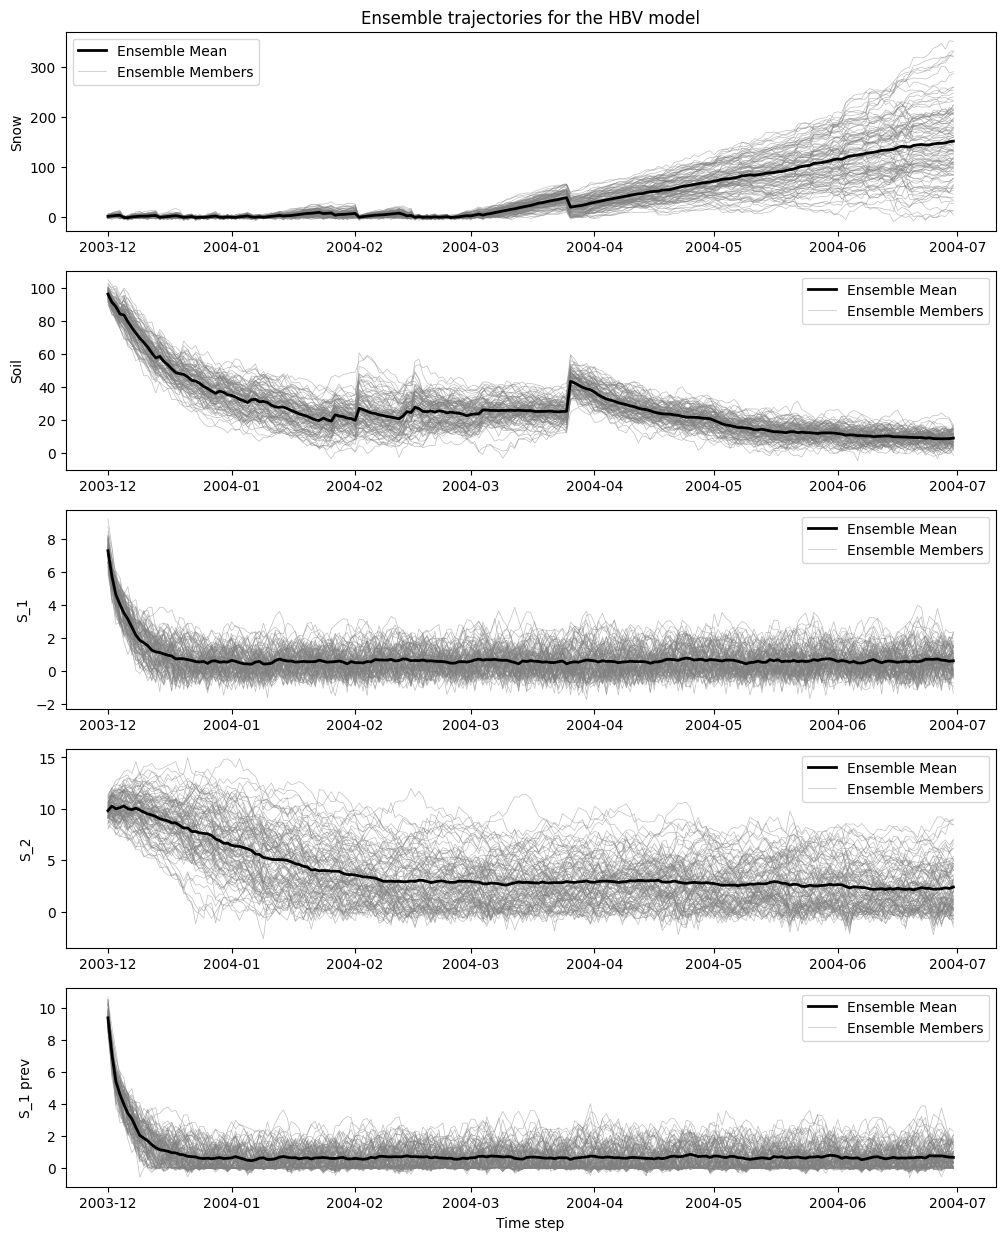

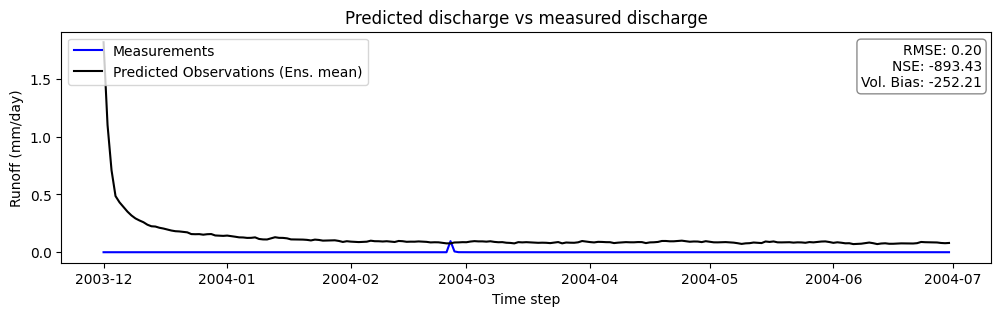

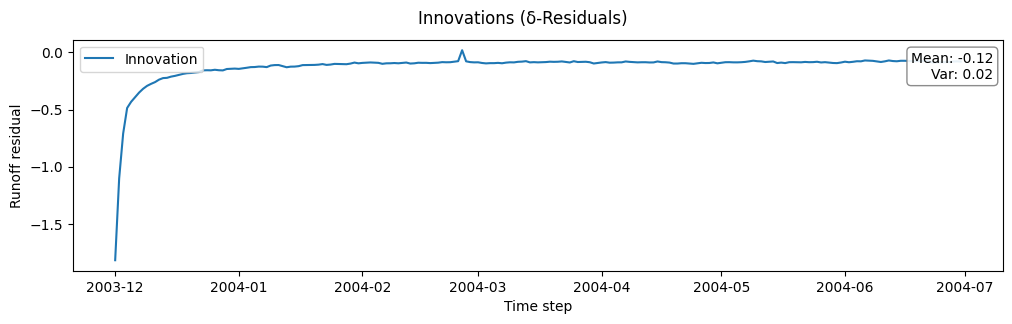

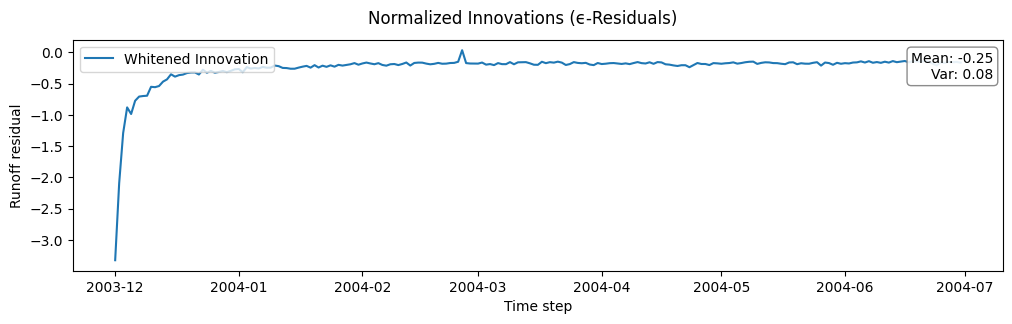

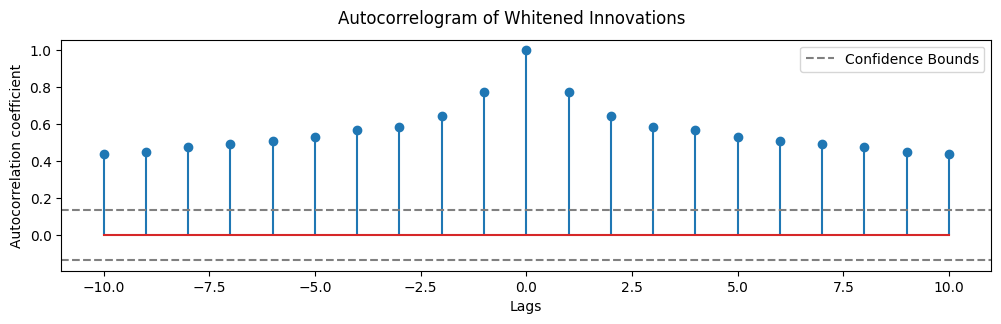

In [42]:
fig = result.plot_ensembles()
axes = fig.get_axes()
axes[0].set_title("Ensemble trajectories for the HBV model")
axes[0].set_ylabel("Snow")
axes[1].set_ylabel("Soil")
axes[2].set_ylabel("S_1")
axes[3].set_ylabel("S_2")
axes[4].set_ylabel("S_1 prev")
axes[4].set_xlabel("Time step")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted discharge vs measured discharge")
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff (mm/day)")

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff residual")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_ylabel("Runoff residual")
ax.set_xlabel("Time step")

fig = result.plot_autocorrelogram()
ax = fig.get_axes()[0]
ax.set_ylabel("Autocorrelation coefficient")
ax.set_xlabel("Lags")

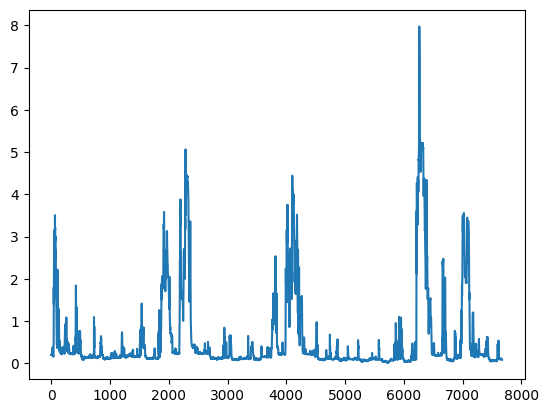

In [22]:
import matplotlib.pyplot as plt
plt.plot(observations[0,:])